<a href="https://colab.research.google.com/github/DevSid300/emotion-recognition-complete-/blob/main/Emotion_Detection_CNN_GradCAM_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Mon Sep 21 15:46:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             30W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
DRIVE_DATASET = "/content/drive/MyDrive/emotion-recognition/data/dataset"

print(os.listdir(DRIVE_DATASET))

['test', 'train']


In [ ]:
LOCAL_DATASET = "/content/dataset"
EXPECTED_CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]


def split_counts(base):
    return {
        c: len(os.listdir(os.path.join(base, c)))
        for c in sorted(os.listdir(base))
        if os.path.isdir(os.path.join(base, c))
    }


# 1) Check the SOURCE on Drive first
src_train = split_counts(f"{DRIVE_DATASET}/train")
src_test = split_counts(f"{DRIVE_DATASET}/test")
print("Drive train:", src_train)
print("Drive test :", src_test)

missing = [c for c in EXPECTED_CLASSES if c not in src_train or c not in src_test]
if missing:
    raise RuntimeError(
        f"Drive dataset is incomplete - missing classes: {missing}. "
        "Re-upload FER-2013 (Kaggle: msambare/fer2013) to Drive, then re-run."
    )

# 2) Re-copy only if the local copy does not match Drive exactly
local_ok = (
    os.path.exists(LOCAL_DATASET)
    and split_counts(f"{LOCAL_DATASET}/train") == src_train
    and split_counts(f"{LOCAL_DATASET}/test") == src_test
)

if local_ok:
    print("\nLocal dataset already exists and matches Drive.")
else:
    if os.path.exists(LOCAL_DATASET):
        print("\nLocal copy is incomplete/stale - deleting and re-copying...")
        shutil.rmtree(LOCAL_DATASET)
    print("Copying dataset from Google Drive to Colab local storage (a few minutes)...")
    shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)
    print("Dataset copied successfully!")

Drive train: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7217, 'neutral': 4965, 'sad': 4857, 'surprise': 3171}
Drive test : {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}

Local dataset already exists and matches Drive.


In [ ]:
TRAIN_DIR = "/content/dataset/train"
TEST_DIR = "/content/dataset/test"

print("Train directory:", TRAIN_DIR)
print("Test directory :", TEST_DIR)

print("\nTrain classes:")
print(sorted(os.listdir(TRAIN_DIR)))

print("\nTest classes:")
print(sorted(os.listdir(TEST_DIR)))

Train directory: /content/dataset/train
Test directory : /content/dataset/test

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
def count_images(base_dir):
    counts = {}

    for emotion in sorted(os.listdir(base_dir)):
        emotion_path = os.path.join(base_dir, emotion)

        if os.path.isdir(emotion_path):
            counts[emotion] = len([
                f for f in os.listdir(emotion_path)
                if os.path.isfile(os.path.join(emotion_path, f))
            ])

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training images:")
for emotion, count in train_counts.items():
    print(f"{emotion:10s}: {count}")

print("\nTest images:")
for emotion, count in test_counts.items():
    print(f"{emotion:10s}: {count}")

print("\nTotal training images:", sum(train_counts.values()))
print("Total test images:", sum(test_counts.values()))

Training images:
angry     : 3995
disgust   : 436
fear      : 4097
happy     : 7217
neutral   : 4965
sad       : 4857
surprise  : 3171

Test images:
angry     : 958
disgust   : 111
fear      : 1024
happy     : 1774
neutral   : 1233
sad       : 1247
surprise  : 831

Total training images: 28738
Total test images: 7178


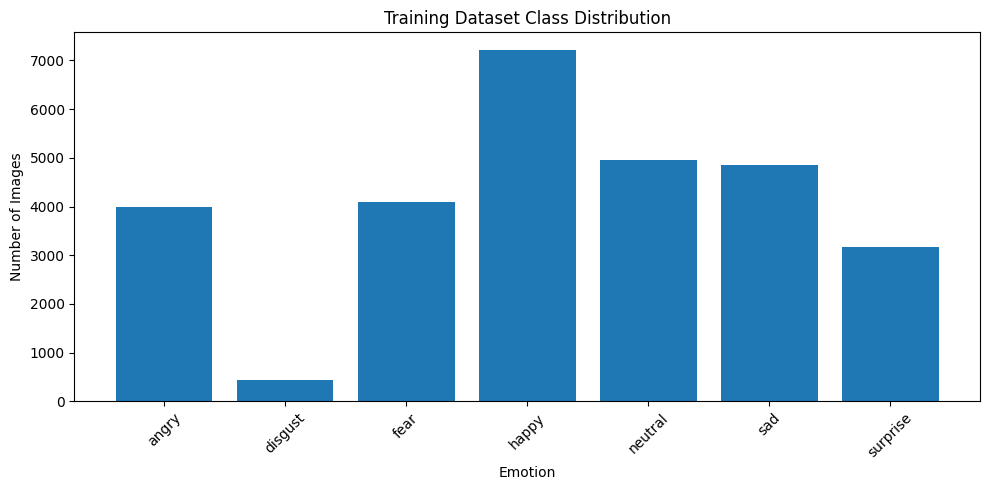

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Dataset Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

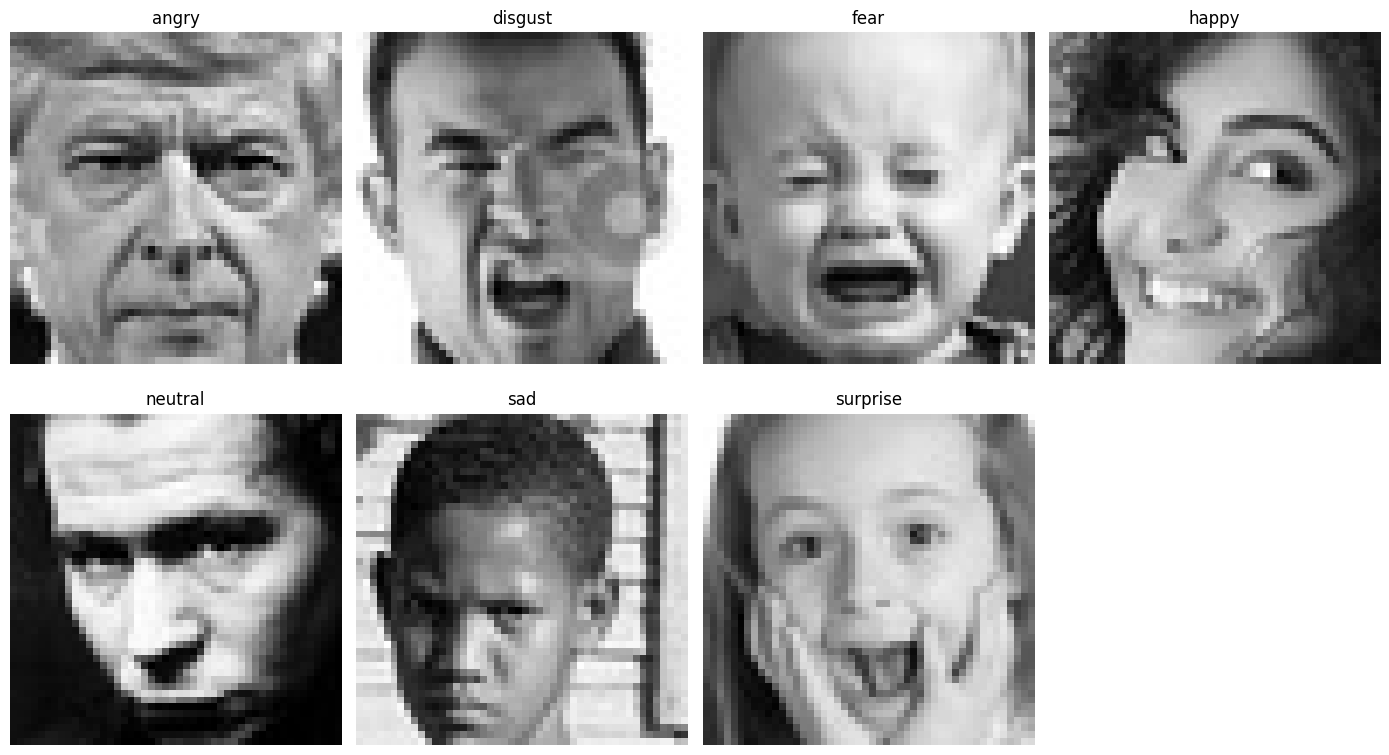

In [ ]:
from tensorflow.keras.utils import load_img

emotion_classes = sorted(train_counts.keys())

plt.figure(figsize=(14, 8))

for i, emotion in enumerate(emotion_classes):

    emotion_folder = os.path.join(TRAIN_DIR, emotion)
    image_files = os.listdir(emotion_folder)

    image_path = os.path.join(
        emotion_folder,
        random.choice(image_files)
    )

    img = load_img(
        image_path,
        color_mode="grayscale",
        target_size=(48, 48)
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print("Mixed precision policy:")
print(mixed_precision.global_policy())

Mixed precision policy:
<DTypePolicy "mixed_float16">


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
NUM_CLASSES = 7

# Augmentation on TRAIN only. Validation/test get rescale only.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.10,
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.10)
test_datagen = ImageDataGenerator(rescale=1./255)

common = dict(target_size=IMG_SIZE, color_mode="grayscale",
              batch_size=BATCH_SIZE, class_mode="categorical")

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, subset="training", shuffle=True, seed=42, **common)

# Same validation_split + same directory => same held-out images, just without augmentation
val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, subset="validation", shuffle=False, seed=42, **common)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, shuffle=False, **common)

assert train_gen.num_classes == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes in train, found {train_gen.num_classes} - "
    "re-run the dataset copy cell.")

Found 25868 images belonging to 7 classes.
Found 2870 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
print("Class indices:")
print(train_gen.class_indices)

print("\nNumber of training samples:", train_gen.samples)
print("Number of validation samples:", val_gen.samples)
print("Number of test samples:", test_gen.samples)

Class indices:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Number of training samples: 25868
Number of validation samples: 2870
Number of test samples: 7178


In [ ]:
images, labels = next(train_gen)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Pixel range:", images.min(), "to", images.max())

Image batch shape: (64, 48, 48, 1)
Label batch shape: (64, 7)
Image data type: float32
Pixel range: 0.0 to 1.0


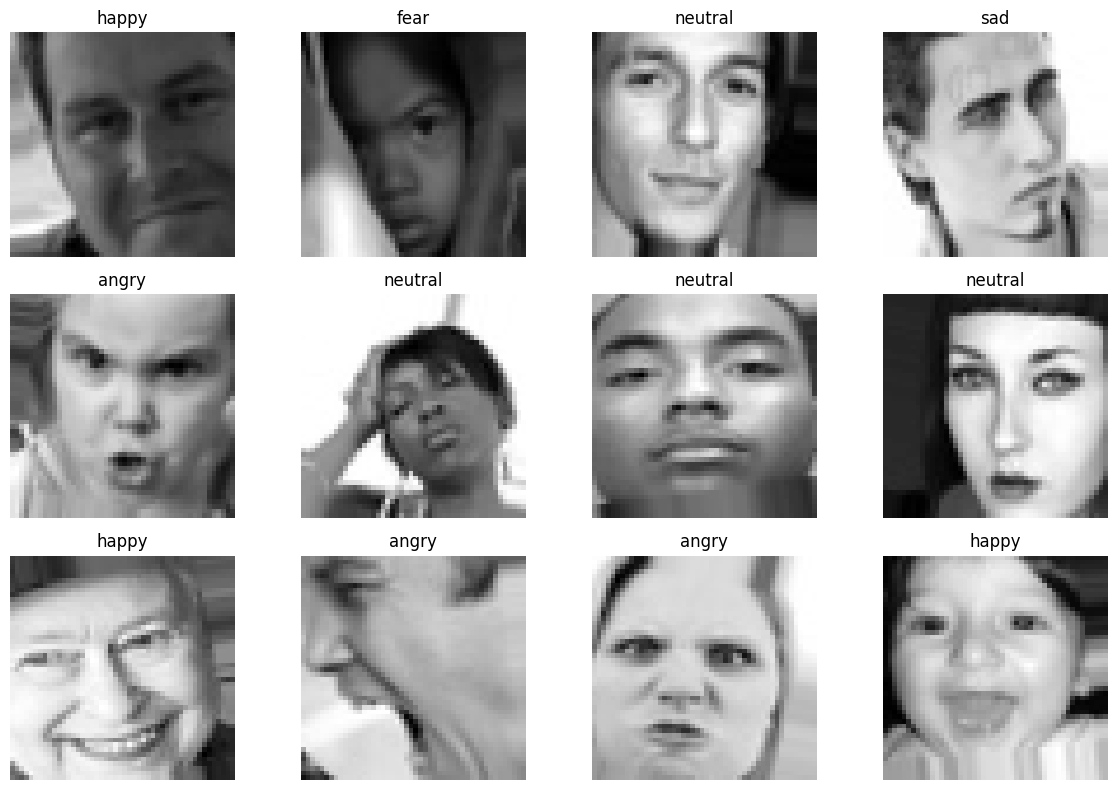

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    label_index = np.argmax(labels[i])
    emotion = list(train_gen.class_indices.keys())[label_index]

    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Class imbalance
`disgust` is ~10x rarer than the other classes. Softened (square-root) class weights help
without the instability of fully "balanced" weights.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_names = [n for n, _ in sorted(train_gen.class_indices.items(), key=lambda kv: kv[1])]

balanced = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_gen.classes)
class_weight = {i: float(np.sqrt(w)) for i, w in enumerate(balanced)}

print("Class weights:")
for i, name in enumerate(class_names):
    print(f"  {name:10s} {class_weight[i]:.2f}")

Class weights:
  angry      1.01
  disgust    3.07
  fear       1.00
  happy      0.75
  neutral    0.91
  sad        0.92
  surprise   1.14


## Model
VGG-style CNN with BatchNorm + Dropout + global average pooling. Blocks 3 and 4 stay at
12x12 resolution so the Grad-CAM heatmaps are not too coarse. The last conv activation is
named `last_conv` and is what Grad-CAM hooks into. The output layer is forced to float32
(required under mixed precision).

In [ ]:
from tensorflow.keras import layers, models, regularizers

L2 = regularizers.l2(1e-4)


def conv_bn_relu(x, filters, name=None):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu", name=name)(x)


def build_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape, name="face")

    x = conv_bn_relu(inputs, 64);  x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D(2)(x); x = layers.Dropout(0.25)(x)          # 24x24

    x = conv_bn_relu(x, 128);      x = conv_bn_relu(x, 128)
    x = layers.MaxPooling2D(2)(x); x = layers.Dropout(0.25)(x)          # 12x12

    x = conv_bn_relu(x, 256);      x = conv_bn_relu(x, 256)
    x = layers.Dropout(0.30)(x)

    x = conv_bn_relu(x, 512);      x = conv_bn_relu(x, 512, name="last_conv")  # Grad-CAM layer

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="emotion")(x)

    return models.Model(inputs, outputs, name="emotion_cnn")


model = build_model(IMG_SIZE + (1,), NUM_CLASSES)
model.summary()

Model: "emotion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ face (InputLayer)               │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 4,824,135 (18.40 MB)

 Trainable params: 4,819,783 (18.39 MB)

 Non-trainable params: 4,352 (17.00 KB)

## Training
The best checkpoint (by validation accuracy) is saved straight to Drive, so a Colab disconnect
will not lose your progress.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

MODEL_DIR = "/content/drive/MyDrive/emotion-recognition/models"
RESULTS_DIR = "/content/drive/MyDrive/emotion-recognition/results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
BEST_PATH = f"{MODEL_DIR}/emotion_cnn_best.keras"

EPOCHS = 60

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # FER-2013 labels are noisy
    metrics=["accuracy"],
)

callbacks = [
    ModelCheckpoint(BEST_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=12, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/60
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.1803 - loss: 2.3868
Epoch 1: val_accuracy improved from None to 0.25122, saving model to /content/drive/MyDrive/emotion-recognition/models/emotion_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/emotion-recognition/models/emotion_cnn_best.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 85s 134ms/step - accuracy: 0.1935 - loss: 2.2386 - val_accuracy: 0.2512 - val_loss: 2.0608 - learning_rate: 0.0010
Epoch 2/60
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2451 - loss: 2.0367
Epoch 2: val_accuracy improved from 0.25122 to 0.32265, saving model to /content/drive/MyDrive/emotion-recognition/models/emotion_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/emotion-recognition/models/emotion_cnn_best.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.2647 - loss: 1.9936 - val_accuracy: 0.3226 - val_loss: 1.9005 - learning_rate: 0.0010
Epoch 3/60
405/405 ━━━━━━━━━━━━━━━━

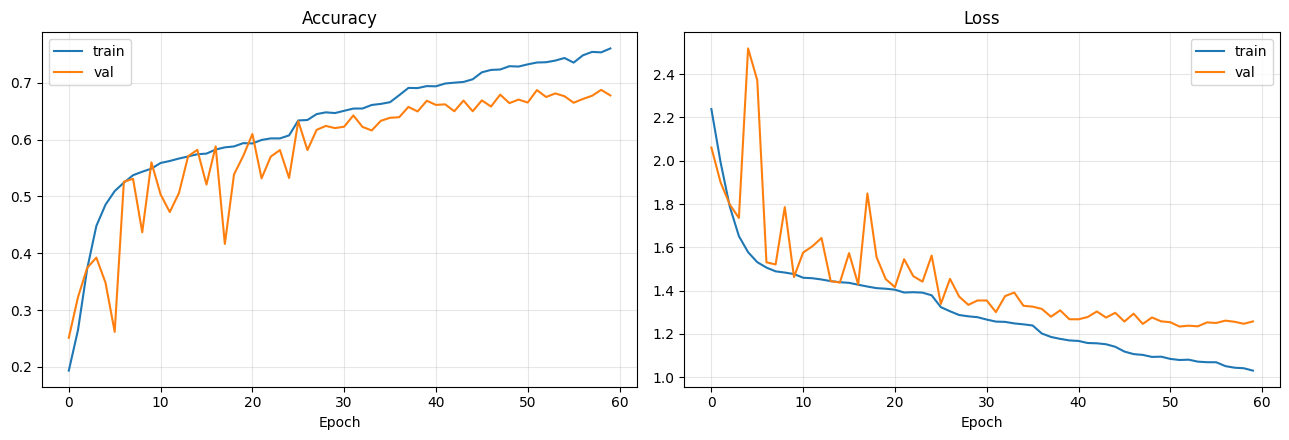

Best val accuracy: 0.6875


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150)
plt.show()

print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")

## Switch to float32 for evaluation, Grad-CAM and deployment
Mixed precision is only useful for training speed. For gradients (Grad-CAM) and for shipping
the model to a laptop CPU, a clean float32 copy is safer. Weights are transferred from the
best checkpoint.

In [ ]:
mixed_precision.set_global_policy("float32")

best = tf.keras.models.load_model(BEST_PATH)
infer_model = build_model(IMG_SIZE + (1,), NUM_CLASSES)
infer_model.set_weights(best.get_weights())
del best

infer_model.compile(loss="categorical_crossentropy", metrics=["accuracy"])
print("Float32 inference model ready. Last conv layer:", infer_model.get_layer("last_conv").output.shape)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Float32 inference model ready. Last conv layer: (None, 12, 12, 512)


## Evaluation on the held-out test set
The test set was never used for training, early stopping, or checkpoint selection.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = infer_model.evaluate(test_gen, verbose=0)
print(f"Test accuracy: {test_acc:.4f}   |   Test loss: {test_loss:.4f}\n")

test_gen.reset()
y_prob = infer_model.predict(test_gen, verbose=0)
y_pred = y_prob.argmax(axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Test accuracy: 0.6771   |   Test loss: 1.0184

              precision    recall  f1-score   support

       angry      0.546     0.665     0.600       958
     disgust      0.837     0.649     0.731       111
        fear      0.538     0.460     0.496      1024
       happy      0.915     0.854     0.884      1774
     neutral      0.602     0.674     0.636      1233
         sad      0.578     0.552     0.565      1247
    surprise      0.784     0.777     0.781       831

    accuracy                          0.677      7178
   macro avg      0.686     0.662     0.670      7178
weighted avg      0.683     0.677     0.678      7178



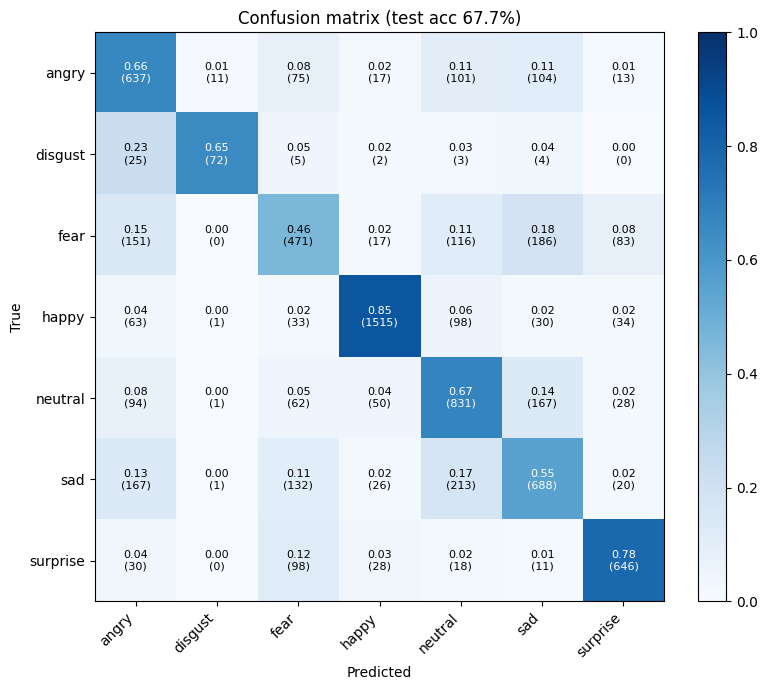

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Confusion matrix (test acc {test_acc:.1%})")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i, j]})", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)

plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## Grad-CAM
Grad-CAM weights each feature map of the last conv layer by the average gradient of the
predicted class score, sums them, applies ReLU and upsamples - showing *which face regions
drove the prediction*.

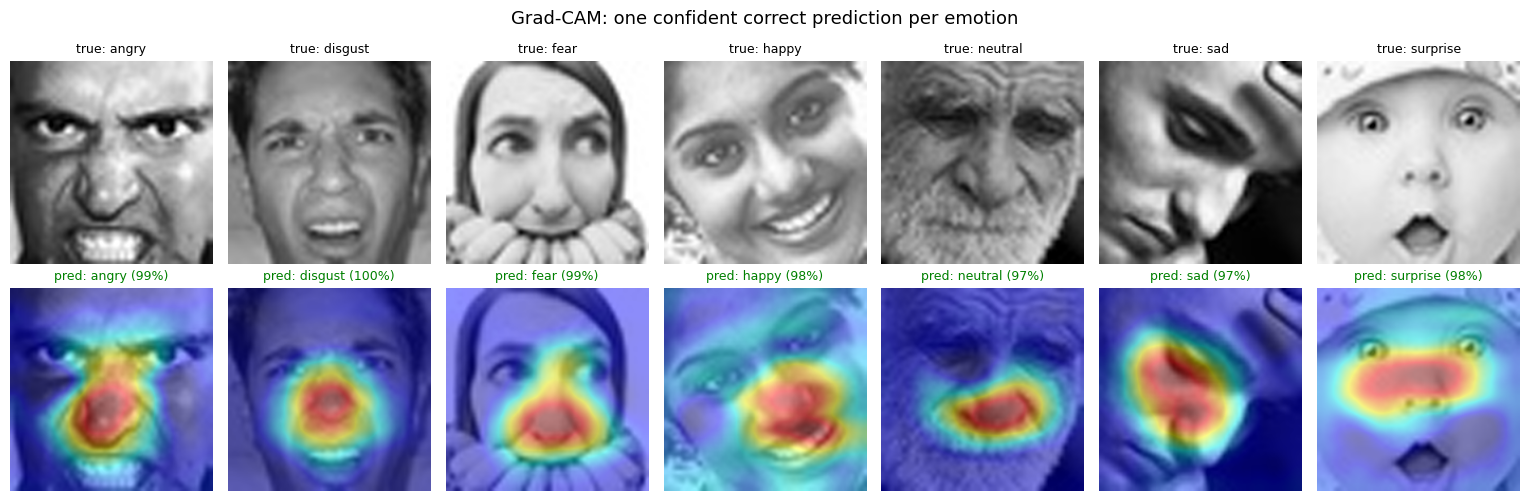

In [ ]:
import cv2
from tensorflow.keras.utils import load_img, img_to_array


def build_gradcam(model, layer_name="last_conv"):
    grad_model = tf.keras.Model(model.input, [model.get_layer(layer_name).output, model.output])

    def gradcam(img_batch, class_idx=None):
        # img_batch: (1, 48, 48, 1) float32 in [0, 1]
        with tf.GradientTape() as tape:
            conv_out, preds = grad_model(img_batch, training=False)
            if class_idx is None:
                class_idx = int(tf.argmax(preds[0]))
            score = preds[:, class_idx]
        grads = tape.gradient(score, conv_out)
        weights = tf.reduce_mean(grads, axis=(1, 2))                  # (1, C)
        cam = tf.reduce_sum(conv_out * weights[:, None, None, :], axis=-1)[0]
        cam = tf.nn.relu(cam)
        cam = cam / (tf.reduce_max(cam) + 1e-8)
        return cam.numpy(), preds[0].numpy(), class_idx

    return gradcam


def overlay_heatmap(gray01, cam, alpha=0.45, size=192):
    # gray01: (48, 48) in [0, 1]; cam: (h, w) in [0, 1]
    base = cv2.resize((gray01 * 255).astype("uint8"), (size, size), interpolation=cv2.INTER_CUBIC)
    base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)
    cam_up = np.clip(cv2.resize(cam, (size, size), interpolation=cv2.INTER_CUBIC), 0, 1)
    heat = cv2.applyColorMap((cam_up * 255).astype("uint8"), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(base, 1 - alpha, heat, alpha, 0), base


gradcam = build_gradcam(infer_model)


def load_test_image(idx):
    img = load_img(test_gen.filepaths[idx], color_mode="grayscale", target_size=IMG_SIZE)
    return img_to_array(img)[..., 0] / 255.0


def show_gradcam(indices, title, save_as=None):
    n = len(indices)
    fig, axes = plt.subplots(2, n, figsize=(max(2.2 * n, 3.5), 5.2), squeeze=False)
    for k, idx in enumerate(indices):
        g = load_test_image(idx)
        cam, probs, pred = gradcam(g[None, ..., None].astype("float32"))
        overlay, base = overlay_heatmap(g, cam)
        axes[0, k].imshow(base); axes[0, k].axis("off")
        axes[0, k].set_title(f"true: {class_names[y_true[idx]]}", fontsize=9)
        axes[1, k].imshow(overlay); axes[1, k].axis("off")
        axes[1, k].set_title(f"pred: {class_names[pred]} ({probs[pred]:.0%})", fontsize=9,
                             color="green" if pred == y_true[idx] else "red")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save_as:
        plt.savefig(f"{RESULTS_DIR}/{save_as}", dpi=150)
    plt.show()


# One correctly-classified example per emotion
per_class = []
for c in range(NUM_CLASSES):
    hits = np.where((y_true == c) & (y_pred == c))[0]
    if len(hits):
        per_class.append(int(hits[np.argmax(y_prob[hits, c])]))   # most confident correct one
show_gradcam(per_class, "Grad-CAM: one confident correct prediction per emotion", "gradcam_per_class.png")

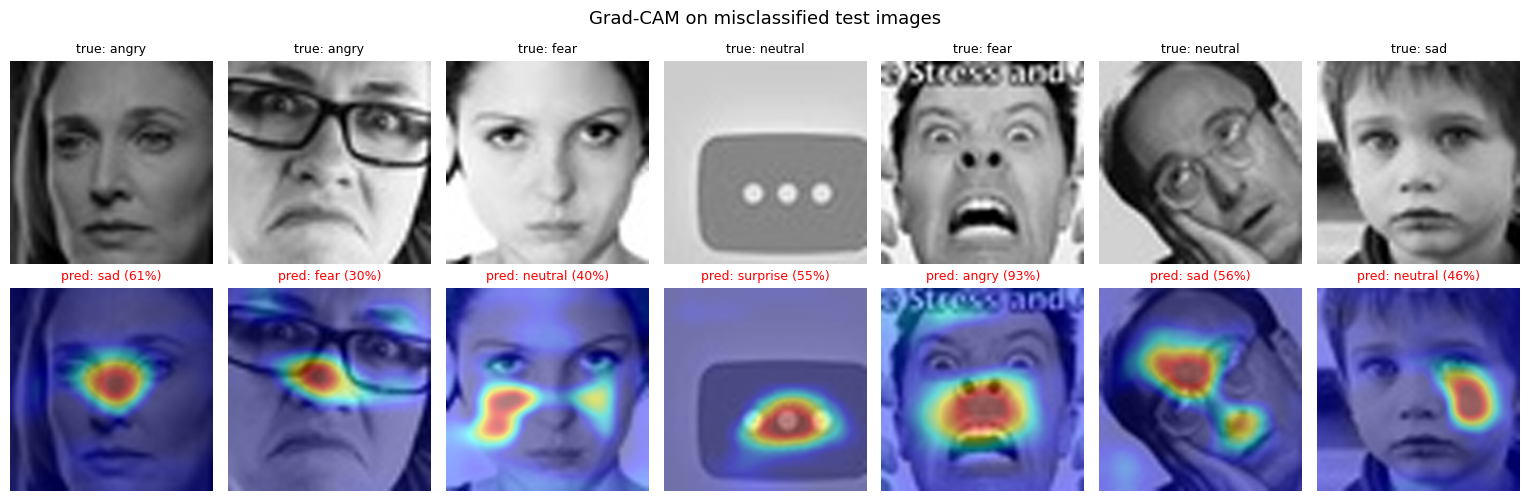

In [ ]:
# What does the model look at when it is WRONG?
wrong = np.where(y_pred != y_true)[0]
rng = np.random.default_rng(0)
show_gradcam(rng.choice(wrong, min(7, len(wrong)), replace=False).tolist(),
             "Grad-CAM on misclassified test images", "gradcam_errors.png")

## Try it on your own photo
Upload any photo with a face. OpenCV's Haar cascade finds faces, each crop is resized to 48x48
grayscale, then classified with a Grad-CAM overlay.

In [ ]:
import cv2
print(cv2.__version__)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
print("Loaded successfully:", not face_cascade.empty())

4.10.0
Loaded successfully: True


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import base64
from google.colab import files
from google.colab.output import eval_js
from IPython.display import display, Javascript, Image, clear_output

# Load Haar cascade classifier
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
IMG_SIZE = (48, 48)

def process_and_display(bgr_image):
    """Detect faces, compute Grad-CAM, and plot side-by-side."""
    if bgr_image is None:
        print("Failed to load image.")
        return

    gray = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(48, 48))
    print(f"Found {len(faces)} face(s)")
    if len(faces) == 0:
        return

    fig, axes = plt.subplots(1, len(faces) + 1, figsize=(4 * (len(faces) + 1), 4.2))
    axes = np.atleast_1d(axes)
    vis = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB).copy()

    for k, (x, y, w, h) in enumerate(faces):
        face = cv2.resize(gray[y:y + h, x:x + w], IMG_SIZE, interpolation=cv2.INTER_AREA) / 255.0
        cam, probs, pred = gradcam(face[None, ..., None].astype("float32"))
        overlay, _ = overlay_heatmap(face, cam)
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
        axes[k + 1].imshow(overlay)
        axes[k + 1].axis("off")
        axes[k + 1].set_title(f"face {k + 1}: {class_names[pred]} ({probs[pred]:.0%})")

    axes[0].imshow(vis)
    axes[0].axis("off")
    axes[0].set_title("detections")
    plt.tight_layout()
    plt.show()

def capture_from_webcam():
    """Starts camera feed with a 'Capture' button and returns the captured image."""
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Photo';
      capture.style.display = 'block';
      capture.style.margin = '10px 0';
      capture.style.padding = '8px 16px';
      capture.style.fontSize = '14px';
      capture.style.cursor = 'pointer';

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: {width: 640, height: 480}});

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      // Wait for the user to click 'Capture'
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', 0.85);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    # Decode base64 to OpenCV BGR array
    img_bytes = base64.b64decode(data.split(',')[1])
    np_arr = np.frombuffer(img_bytes, dtype=np.uint8)
    return cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# --- Selection Menu ---
print("Choose input method:")
print("1. Upload an image file")
print("2. Use webcam to click a picture")
choice = input("Enter 1 or 2: ").strip()

if choice == "1":
    uploaded = files.upload()
    for fname in uploaded:
        img = cv2.imread(fname)
        process_and_display(img)
elif choice == "2":
    print("Opening webcam. Click the 'Capture Photo' button when ready...")
    img = capture_from_webcam()
    clear_output()
    process_and_display(img)
else:
    print("Invalid option selected. Please re-run the cell and enter 1 or 2.")

Choose input method:
1. Upload an image file
2. Use webcam to click a picture
Enter 1 or 2: 1


Saving WhatsApp Image 2026-09-21 at 21.56.16.jpeg to WhatsApp Image 2026-09-21 at 21.56.16 (2).jpeg
Found 0 face(s)


## Export for real-time inference
Saves the float32 model + label list to Drive and downloads them. Put both files next to
`realtime_emotion.py` and run it on a laptop with a webcam.

In [ ]:
FINAL_PATH = f"{MODEL_DIR}/emotion_cnn_final.keras"
infer_model.save(FINAL_PATH)

with open(f"{MODEL_DIR}/labels.json", "w") as f:
    json.dump(class_names, f)

print("Saved:", FINAL_PATH)
print(f"\nFINAL TEST ACCURACY: {test_acc:.2%}  <- use this exact number on your resume/README")

files.download(FINAL_PATH)
files.download(f"{MODEL_DIR}/labels.json")

Saved: /content/drive/MyDrive/emotion-recognition/models/emotion_cnn_final.keras

FINAL TEST ACCURACY: 67.71%  <- use this exact number on your resume/README


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>